## Basic Overview


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

In [34]:
df = pd.read_csv("./data/magnet_dataset.csv")

print("Shape:", df.shape)

Shape: (52205, 19)


In [35]:
print("\nColumn types:\n")
df.dtypes


Column types:



material_id                   str
formula                       str
elements                      str
nelements                   int64
nsites                      int64
volume                    float64
density                   float64
energy_above_hull         float64
formation_energy          float64
band_gap                  float64
total_magnetization       float64
magnetization_norm_vol    float64
ordering                      str
crystal_system                str
spacegroup_number           int64
spacegroup_symbol             str
is_magnetic                  bool
num_magnetic_sites          int64
magnetic_species              str
dtype: object

In [36]:
print("\nMissing values:\n")
df.isnull().sum()


Missing values:



material_id               0
formula                   3
elements                  0
nelements                 0
nsites                    0
volume                    0
density                   0
energy_above_hull         2
formation_energy          2
band_gap                  0
total_magnetization       0
magnetization_norm_vol    0
ordering                  0
crystal_system            0
spacegroup_number         0
spacegroup_symbol         0
is_magnetic               0
num_magnetic_sites        0
magnetic_species          0
dtype: int64

In [37]:
print("\nBasic stats:\n")
print(df.describe())


Basic stats:

          nelements       nsites        volume       density  \
count  52205.000000  52205.00000  52205.000000  52205.000000   
mean       3.702404     31.27528    472.384278      4.433806   
std        0.874495     26.89800    512.372700      2.091491   
min        1.000000      1.00000     11.030657      0.020562   
25%        3.000000     14.00000    201.815856      3.061785   
50%        4.000000     24.00000    324.753247      4.058095   
75%        4.000000     40.00000    588.958300      5.361677   
max        9.000000    404.00000  20090.906408     22.968174   

       energy_above_hull  formation_energy      band_gap  total_magnetization  \
count       52203.000000      52203.000000  52205.000000         52205.000000   
mean            0.235871         -1.708841      0.648712            12.963110   
std             0.493511          1.153239      0.990172            16.643559   
min             0.000000         -4.422902      0.000000             0.000000   
25%

## Filter Permanent Magnet Candidates


In [38]:
df_pm = df[
    (df["energy_above_hull"] < 0.1) &
    (df["total_magnetization"] > 0.5)
].copy()

print(f"Permanent magnet candidates: {len(df_pm)}")
df_pm.reset_index(drop=True, inplace=True)
df_pm.to_csv("./data/magnet_pm_filtered.csv", index=False)

Permanent magnet candidates: 28472


## Magnetization Distribution


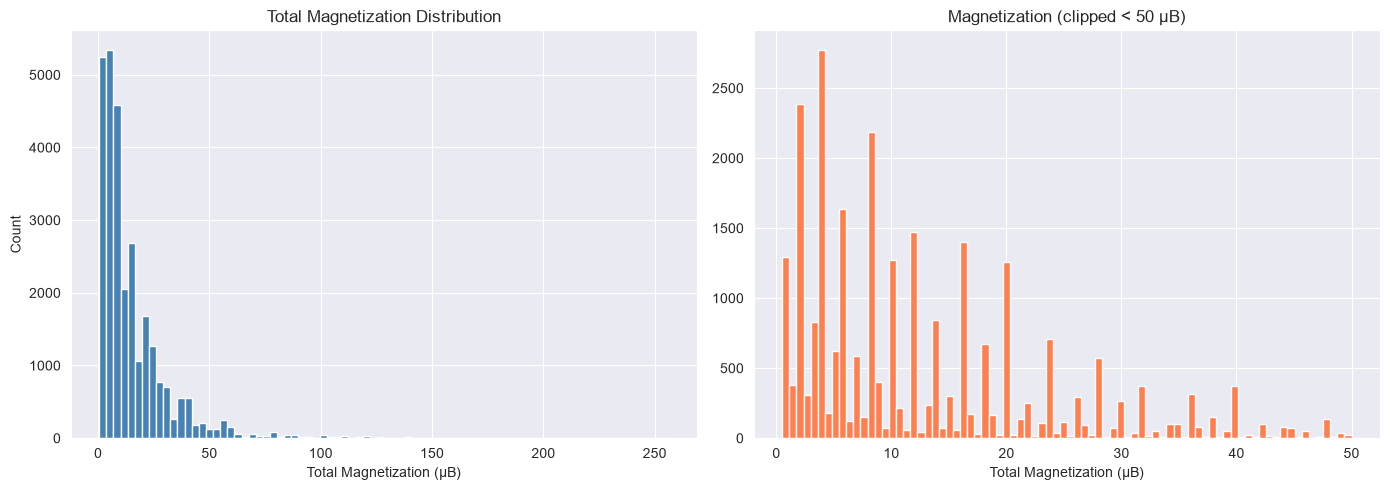

In [39]:
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full range
axes[0].hist(df_pm["total_magnetization"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Total Magnetization Distribution")
axes[0].set_xlabel("Total Magnetization (μB)")
axes[0].set_ylabel("Count")

# Clipped for clarity
clipped = df_pm[df_pm["total_magnetization"] < 50]
axes[1].hist(clipped["total_magnetization"], bins=80, color="coral", edgecolor="white")
axes[1].set_title("Magnetization (clipped < 50 μB)")
axes[1].set_xlabel("Total Magnetization (μB)")

plt.tight_layout()
plt.savefig("./figure/magnetization_dist.png", dpi=150)
plt.show()

### Plot 1 — Magnetization Distribution
- Heavily **right-skewed** — most materials have low magnetization (0–10 μB)
- A few outliers go up to **270 μB** (like Ba3Fe26O41 with 256 μB)
- This means for ML regression, you may need **log transformation** on the target

## Crystal System Distribution


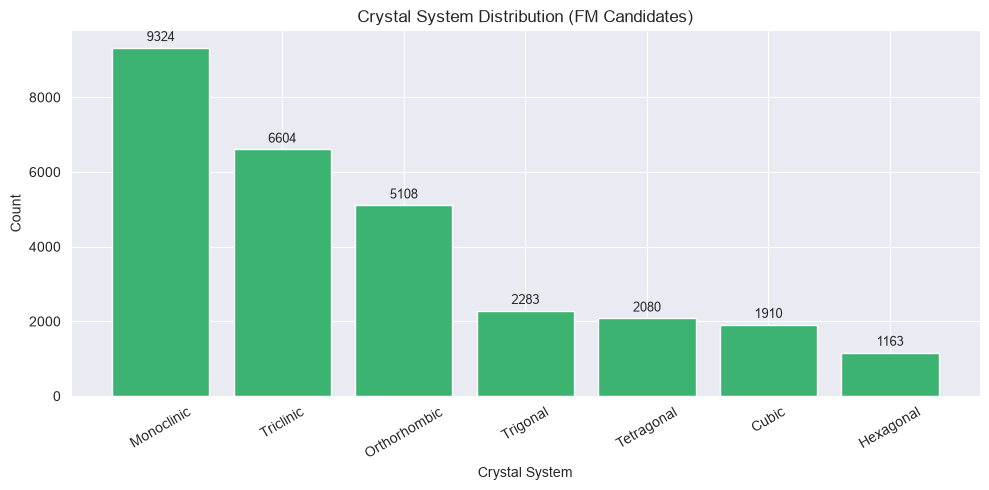

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))

crystal_counts = df_pm["crystal_system"].value_counts()
bars = ax.bar(crystal_counts.index, crystal_counts.values, color="mediumseagreen", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("Crystal System Distribution (FM Candidates)")
ax.set_xlabel("Crystal System")
ax.set_ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("./figure/crystal_system_dist.png", dpi=150)
plt.show()

### Plot 2 — Crystal System
- **Monoclinic (9324)** and **Triclinic (6604)** dominate — these are low-symmetry structures
- **Hexagonal (1163)** is least common but historically produces the strongest real-world magnets (NdFeB is tetragonal, SmCo is hexagonal)
- Interesting mismatch between count and real-world importance


## Top Magnetic Elements


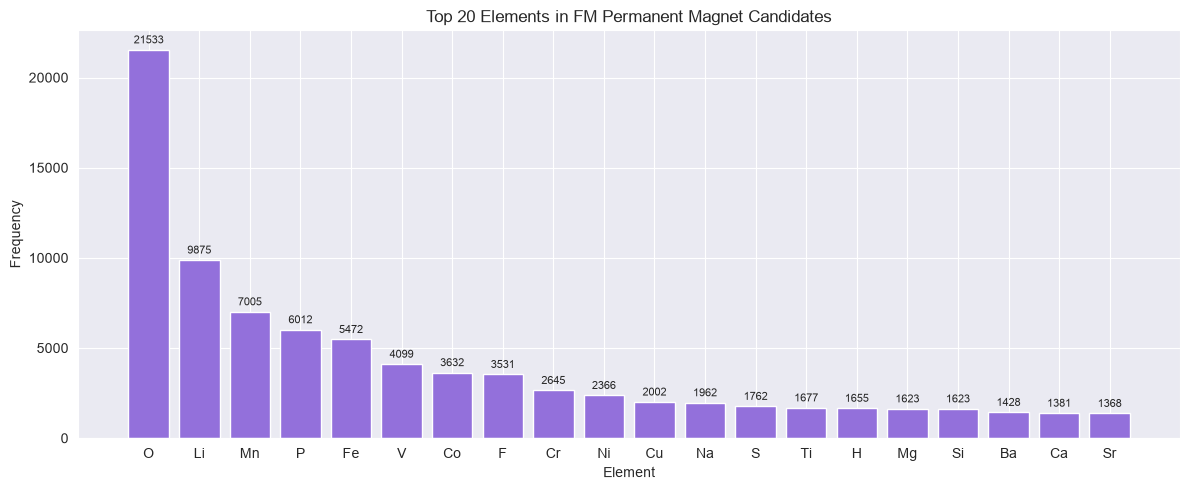

In [41]:
# Parse elements column (stored as string list)
all_elements = []
for row in df_pm["elements"]:
    try:
        elems = ast.literal_eval(row)
        all_elements.extend(elems)
    except:
        pass

elem_counts = Counter(all_elements)
top_elements = pd.DataFrame(elem_counts.most_common(20), columns=["Element", "Count"])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_elements["Element"], top_elements["Count"], color="mediumpurple", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_title("Top 20 Elements in FM Permanent Magnet Candidates")
ax.set_xlabel("Element")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("./figure/top_elements.png", dpi=150)
plt.show()

### Plot 3 — Top Elements
- **O (21533)** dominates — most candidates are oxides
- **Li, Mn, Fe** are next — classic magnetic elements
- Rare earth elements (Nd, Sm) are NOT in top 20 — they're rare in the database but critical in real magnets
- **Insight:** Your ML should flag rare-earth-containing materials specially


## Correlation Heatmap


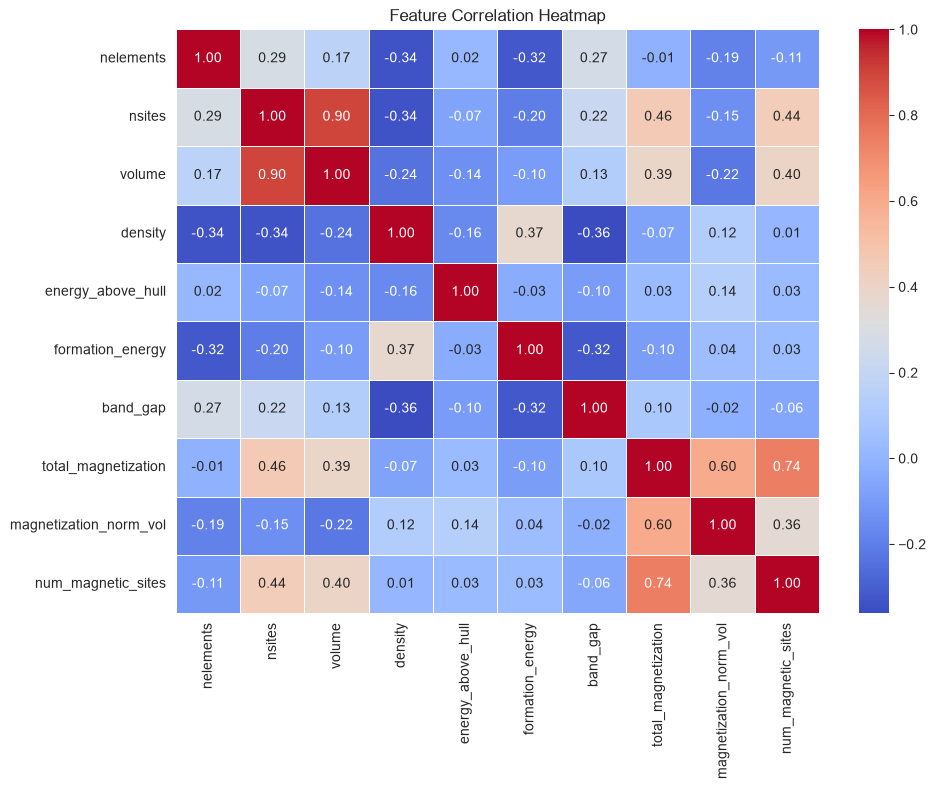

In [42]:
numeric_cols = [
    "nelements", "nsites", "volume", "density",
    "energy_above_hull", "formation_energy",
    "band_gap", "total_magnetization",
    "magnetization_norm_vol", "num_magnetic_sites"
]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_pm[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("./figure/correlation_heatmap.png", dpi=150)
plt.show()

### Plot 4 — Correlation Heatmap
Key findings:
- `total_magnetization` ↔ `num_magnetic_sites`: **0.74** — strong! More magnetic atoms = stronger magnet (makes physical sense)
- `total_magnetization` ↔ `magnetization_norm_vol`: **0.60** — moderate
- `nsites` ↔ `volume`: **0.90** — expected (bigger cell = more atoms)
- `density` ↔ `band_gap`: **-0.36** — denser materials tend to be more metallic
- `energy_above_hull` has **weak correlations** with everything — stability is somewhat independent


## Magnetization vs Stability Scatter


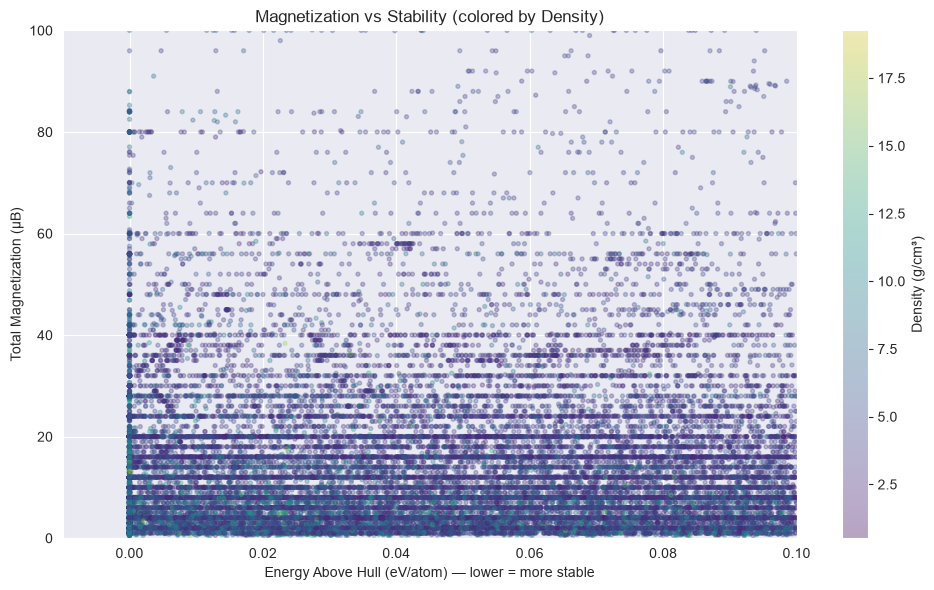

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    df_pm["energy_above_hull"],
    df_pm["total_magnetization"],
    alpha=0.3, s=8,
    c=df_pm["density"], cmap="viridis"
)
plt.colorbar(sc, label="Density (g/cm³)")
ax.set_xlabel("Energy Above Hull (eV/atom) — lower = more stable")
ax.set_ylabel("Total Magnetization (μB)")
ax.set_title("Magnetization vs Stability (colored by Density)")
ax.set_xlim(-0.01, 0.1)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("./figure/mag_vs_stability.png", dpi=150)
plt.show()

### Plot 5 — Magnetization vs Stability
- The **horizontal stripe pattern** is interesting — magnetization takes discrete values (integer multiples of μB per atom)
- Best candidates cluster at **energy_above_hull ≈ 0** (left edge) with high magnetization
- Density doesn't show a strong pattern here

## Top 20 Most Magnetic Stable Materials

In [44]:
top_magnets = df_pm.nlargest(20, "total_magnetization")[
    ["formula", "total_magnetization", "magnetization_norm_vol",
     "energy_above_hull", "crystal_system", "density"]
]

print("🏆 Top 20 Most Magnetic Stable Materials:")
print(top_magnets.to_string(index=False))

🏆 Top 20 Most Magnetic Stable Materials:
       formula  total_magnetization  magnetization_norm_vol  energy_above_hull crystal_system  density
    Ba3Fe26O41           256.235535                0.154248           0.050177      Hexagonal 5.037862
         Mn2O3           256.002669                0.135580           0.078851     Tetragonal 4.442863
    Zn(Fe2O3)4           228.072628                0.159946           0.049661      Triclinic 4.920101
        EuAlF5           224.031574                0.075166           0.000000     Tetragonal 4.883837
      Eu16Sb11           223.998645                0.117525           0.000000   Orthorhombic 6.570463
     Eu4C2N4F5           216.001343                0.126446           0.026794     Tetragonal 6.088232
       LiFe5O8           200.001166                0.169255           0.098856      Triclinic 4.656037
    Mn7(PbO5)3           200.000000                0.078589           0.010116   Orthorhombic 6.504979
       Fe41O56           194.000

### Top 20 Materials — Observations
- **EuAlF5** and **Eu16Sb11** have `energy_above_hull = 0` — perfectly stable AND highly magnetic → excellent candidates
- **Gd2Fe14C** (171 μB, tetragonal, density 8.5) — this is a known real-world strong magnet, validating your dataset!
- Most top materials contain **Mn, Fe, or Eu**